In [1]:
# CELLULE 1 - Imports et chargement des données preprocessées
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, f1_score, recall_score,
                             precision_score, accuracy_score,
                             RocCurveDisplay, PrecisionRecallDisplay)
from sklearn.model_selection import StratifiedKFold, cross_val_score
import joblib
import warnings
warnings.filterwarnings('ignore')

COLOR_BLUE  = "#163767"
COLOR_RED   = "#E53935"
COLOR_GREEN = "#43A047"

# Chargement des données preprocessées
X_train = np.load('../data/processed/X_train.npy')
X_test  = np.load('../data/processed/X_test.npy')
y_train = np.load('../data/processed/y_train.npy')
y_test  = np.load('../data/processed/y_test.npy')

print(f"X_train : {X_train.shape} | X_test : {X_test.shape}")
print(f"Proportion pannes train : {y_train.mean():.1%}")

X_train : (19233, 14) | X_test : (4809, 14)
Proportion pannes train : 14.8%


On a créé une fonction commune pour évaluer tous les modèles avec les mêmes métriques. Le Recall est notre métrique prioritaire car rater une panne est bien plus grave que déclencher une fausse alarme."

In [ ]:
# CELLULE 2 - Fonction d evaluation commune
from sklearn.metrics import average_precision_score
#y_test = relaity
def evaluate_model(name, model, X_test, y_test, results={}):
    y_pred  = model.predict(X_test)# → prédit 0 ou 1 pour chaque ligne
    y_proba = model.predict_proba(X_test)[:, 1] # → prédit une probabilité entre 0 et 1

    #Les 6 métriques
    results[name] = {
        'Accuracy':  accuracy_score(y_test, y_pred),  #Accuracy = % de bonnes prédictions au total
        'Precision': precision_score(y_test, y_pred), #Precision = parmi les pannes prédites VP FP , combien sont vraiment des pannes  ?
        'Recall':    recall_score(y_test, y_pred), #Recall = parmi les vraies pannes VP FN, combien on a détectées ?
        'F1':        f1_score(y_test, y_pred), #F1 = équilibre entre Precision et Recall
        'ROC-AUC':   roc_auc_score(y_test, y_proba), #ROC-AUC = capacité globale à distinguer pannes et machines saines + Plus c'est proche de 1, mieux c'est.
        'PR-AUC':    average_precision_score(y_test, y_proba) #PR-AUC = comme ROC-AUC mais adapté aux datasets déséquilibrés
    }

    sep = '=' * 50
    print()
    print(sep)
    print('  ' + name)
    print(sep)
    print(classification_report(y_test, y_pred,
          target_names=['Pas de panne', 'Panne']))
    roc = results[name]['ROC-AUC']
    prauc = results[name]['PR-AUC']
    print(f'ROC-AUC : {roc:.4f}')
    print(f'PR-AUC  : {prauc:.4f}  <- metrique cle (desequilibre)')

    return results

results = {}
print('Fonction d evaluation prete')


Fonction d evaluation prete


On crée le modèle avec 3 paramètres :
random_state=42 → résultats toujours identiques à chaque exécution
max_iter=1000 → le modèle a droit à 1000 tentatives pour trouver la meilleure règle
class_weight='balanced' → gère le déséquilibre !

why 42  = En pratique, n'importe quel chiffre marche. L'important c'est que ce soit toujours le même pour avoir des résultats reproductible
why 1000 = La Logistic Regression cherche la meilleure règle en faisant des essais successifs. 

Le paramètre class_weight='balanced' calcule automatiquement le ratio de déséquilibre — ici 5.8 — et pondère les erreurs en conséquence. Une erreur sur une panne est donc 5.8 fois plus pénalisée.

logistic regression = Il apprend une règle linéaire :
Si (température × 0.4) + (vibration × 0.3) + ... > seuil → PANNE
Sinon → PAS DE PANNE
Simple et rapide mais limité — il ne voit que des relations directes entre les variables.

processu complet du model : 
Étape 1 : Entraînement
pythonlr.fit(X_train, y_train)
Le modèle regarde X_train et y_train ensemble
Il apprend : "quand temperature=85°C et vibration=6, c'est souvent une panne"
Il mémorise ces règles
etape 2 : prediction  On lui donne X_test sans y_test
Il applique les règles apprises sur ces nouvelles données
Il prédit 0 ou 1 pour chaque ligne
Étape 3 : Évaluation
pythonevaluate_model('Logistic Regression', lr, X_test, y_test)
On compare y_pred (ses prédictions) avec y_test (la réalité)
On calcule ses métriques

La différence entre preprocessor et modèle
preprocessor.fit  → apprend à NETTOYER les données
                    (médiane, écart-type, catégories...)

lr.fit            → apprend à PRÉDIRE les pannes
                    (règles entre capteurs et pannes)

In [3]:
# CELLULE 3 - Modele 1 : Logistic Regression (baseline)
lr = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr.fit(X_train, y_train)

results = evaluate_model('Logistic Regression', lr, X_test, y_test, results)

joblib.dump(lr, '../models/logistic_regression.joblib')


  Logistic Regression
              precision    recall  f1-score   support

Pas de panne       0.98      0.91      0.95      4097
       Panne       0.64      0.89      0.75       712

    accuracy                           0.91      4809
   macro avg       0.81      0.90      0.85      4809
weighted avg       0.93      0.91      0.92      4809

ROC-AUC : 0.9588
PR-AUC  : 0.8376  <- metrique cle (desequilibre)


['../models/logistic_regression.joblib']

C'est quoi un Random Forest ?
Le Random Forest c'est différent — il crée 100 arbres de décision et les fait voter ensemble.

C'est quoi un arbre de décision ?
C'est une série de questions :
temperature > 70°C ?
    OUI → vibration > 3 ?
              OUI → PANNE 
              NON → pas de panne 
    NON → rpm > 2000 ?
              OUI → pas de panne 
              NON → pas de panne 
Un seul arbre peut se tromper. Mais 100 arbres qui votent ensemble → beaucoup plus fiable !

In [ ]:
# CELLULE 4 - Modele 2 : Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, 
                             class_weight='balanced', n_jobs=-1) #n_jobs=-1 → utilise tous les cœurs du processeur pour aller plus vite
rf.fit(X_train, y_train)

results = evaluate_model('Random Forest', rf, X_test, y_test, results)

joblib.dump(rf, '../models/random_forest.joblib')


  Random Forest
              precision    recall  f1-score   support

Pas de panne       0.98      0.98      0.98      4097
       Panne       0.90      0.88      0.89       712

    accuracy                           0.97      4809
   macro avg       0.94      0.93      0.94      4809
weighted avg       0.97      0.97      0.97      4809

ROC-AUC : 0.9938
PR-AUC  : 0.9662  <- metrique cle (desequilibre)


['../models/random_forest.joblib']

Le Random Forest obtient un Recall de 0.88 sur les pannes  on détecte 88% des vraies pannes. La Precision de 0.90 signifie peu de fausses alarmes 0,1 . Le ROC-AUC de 0.9938 est excellent .

In [5]:
import subprocess
import sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xgboost'])

0

C'est quoi XGBoost ?
Random Forest crée 100 arbres en parallèle et ils votent ensemble.
XGBoost c'est différent  il crée les arbres en séquence :
Arbre 1 → fait des erreurs
Arbre 2 → apprend des erreurs de l'arbre 1, les corrige
Arbre 3 → apprend des erreurs de l'arbre 2, les corrige
...
Arbre 100 → modèle très précis !
C'est ce qu'on appelle le Gradient Boosting  , chaque arbre améliore le précédent.

In [ ]:
# CELLULE 5 - Modele 3 : Gradient Boosting (XGBoost)
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()  #C'est l'équivalent de class_weight='balanced' mais pour XGBoost = Une erreur sur une panne est 5.75 fois plus pénalisée !


xgb = XGBClassifier(n_estimators=100, random_state=42,
                    scale_pos_weight=scale_pos_weight,
                    eval_metric='logloss', verbosity=0)
xgb.fit(X_train, y_train) 

results = evaluate_model('XGBoost', xgb, X_test, y_test, results)

joblib.dump(xgb, '../models/xgboost.joblib')


  XGBoost
              precision    recall  f1-score   support

Pas de panne       0.99      0.98      0.98      4097
       Panne       0.88      0.96      0.92       712

    accuracy                           0.97      4809
   macro avg       0.94      0.97      0.95      4809
weighted avg       0.98      0.97      0.97      4809

ROC-AUC : 0.9955
PR-AUC  : 0.9741  <- metrique cle (desequilibre)


['../models/xgboost.joblib']

Il obtient un Recall de 0.93, une Precision de 0.95 et un ROC-AUC de 0.9955.

In [7]:
import subprocess
import sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'tensorflow'])

0

C'est quoi un MLP ?
MLP = Multi-Layer Perceptron = un réseau de neurones.
C'est inspiré du cerveau humain  des neurones connectés entre eux.
Entrée (14 variables)
       ↓
Couche 1 : 128 neurones  ← apprend des patterns complexes
       ↓
Couche 2 : 64 neurones   ← affine les patterns
       ↓
Couche 3 : 32 neurones   ← affine encore
       ↓
Sortie : 1 neurone       ← probabilité de panne (entre 0 et 1)
Dense(128) → une couche de 128 neurones connectés à tous les neurones précédents
activation='relu' → fonction mathématique qui dit :
Si valeur < 0 → met 0
Si valeur > 0 → garde la valeur
→ permet au réseau d'apprendre des relations complexes non linéaires
BatchNormalization() → normalise les valeurs entre chaque couche

→ stabilise l'apprentissage, va plus vite
Dropout(0.3) → pendant l'entraînement, éteint 30% des neurones aléatoirement

→ force le réseau à ne pas trop dépendre d'un seul neurone

→ évite le surapprentissage (mémoriser au lieu d'apprendre)
activation='sigmoid' → la dernière couche sort une valeur entre 0 et 1

→ c'est la probabilité de pann

Le nombre de neurones est un hyperparamètre qu'on choisit par expérimentation. On a testé plusieurs valeurs et 128 offre le meilleur compromis entre performance et temps de calcul."

In [8]:
# CELLULE 6 - Modele 4 : MLP (Deep Learning)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

model_mlp = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_mlp.compile(optimizer=Adam(learning_rate=0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Poids des classes pour gérer le déséquilibre
class_weight = {0: 1.0, 1: (y_train == 0).sum() / (y_train == 1).sum()}

history = model_mlp.fit(X_train, y_train,
                        epochs=100,
                        batch_size=256,
                        validation_split=0.2,
                        class_weight=class_weight,
                        callbacks=[early_stop],
                        verbose=1)

Epoch 1/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7505 - loss: 0.8082 - val_accuracy: 0.9067 - val_loss: 0.5043
Epoch 2/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8867 - loss: 0.5202 - val_accuracy: 0.9259 - val_loss: 0.3364
Epoch 3/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8969 - loss: 0.4394 - val_accuracy: 0.9324 - val_loss: 0.2293
Epoch 4/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9068 - loss: 0.4172 - val_accuracy: 0.9329 - val_loss: 0.2015
Epoch 5/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9110 - loss: 0.3768 - val_accuracy: 0.9353 - val_loss: 0.1782
Epoch 6/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9087 - loss: 0.3744 - val_accuracy: 0.9350 - val_loss: 0.1693
Epoch 7/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9129 - loss: 0.3534 - val_accuracy: 0.9244 - val_loss: 0.1813
Epoch 8/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9134 - loss: 0.3433 - val_accuracy: 0.9270 - v

In [9]:
print("MLP termine !")
print(f"Nombre d'epochs effectues : {len(history.history['loss'])}")

MLP termine !
Nombre d'epochs effectues : 16


In [10]:
# CELLULE 7 - Evaluation MLP
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score

y_proba_mlp = model_mlp.predict(X_test, verbose=0).flatten()
y_pred_mlp = (y_proba_mlp >= 0.5).astype(int)

results['MLP'] = {
    'Accuracy':  accuracy_score(y_test, y_pred_mlp),
    'Precision': precision_score(y_test, y_pred_mlp),
    'Recall':    recall_score(y_test, y_pred_mlp),
    'F1':        f1_score(y_test, y_pred_mlp),
    'ROC-AUC':   roc_auc_score(y_test, y_proba_mlp),
    'PR-AUC':    average_precision_score(y_test, y_proba_mlp)
}

print("MLP (Deep Learning)")
print("="*50)
print(classification_report(y_test, y_pred_mlp,
      target_names=['Pas de panne', 'Panne']))
print(f"ROC-AUC : {results['MLP']['ROC-AUC']:.4f}")
print(f"PR-AUC  : {results['MLP']['PR-AUC']:.4f}")

model_mlp.save('../models/mlp_model.keras')
print("Modele sauvegarde")


MLP (Deep Learning)
              precision    recall  f1-score   support

Pas de panne       0.98      0.94      0.96      4097
       Panne       0.72      0.88      0.80       712

    accuracy                           0.93      4809
   macro avg       0.85      0.91      0.88      4809
weighted avg       0.94      0.93      0.94      4809

ROC-AUC : 0.9718
PR-AUC  : 0.8526
Modele sauvegarde


COMPARAISON DES 4 MODELES
                     Accuracy  Precision  Recall      F1  ROC-AUC  PR-AUC
XGBoost                0.9744     0.8820  0.9551  0.9171   0.9955  0.9741
Random Forest          0.9682     0.9010  0.8820  0.8914   0.9938  0.9662
MLP                    0.9326     0.7225  0.8848  0.7955   0.9718  0.8526
Logistic Regression    0.9102     0.6408  0.8947  0.7468   0.9588  0.8376


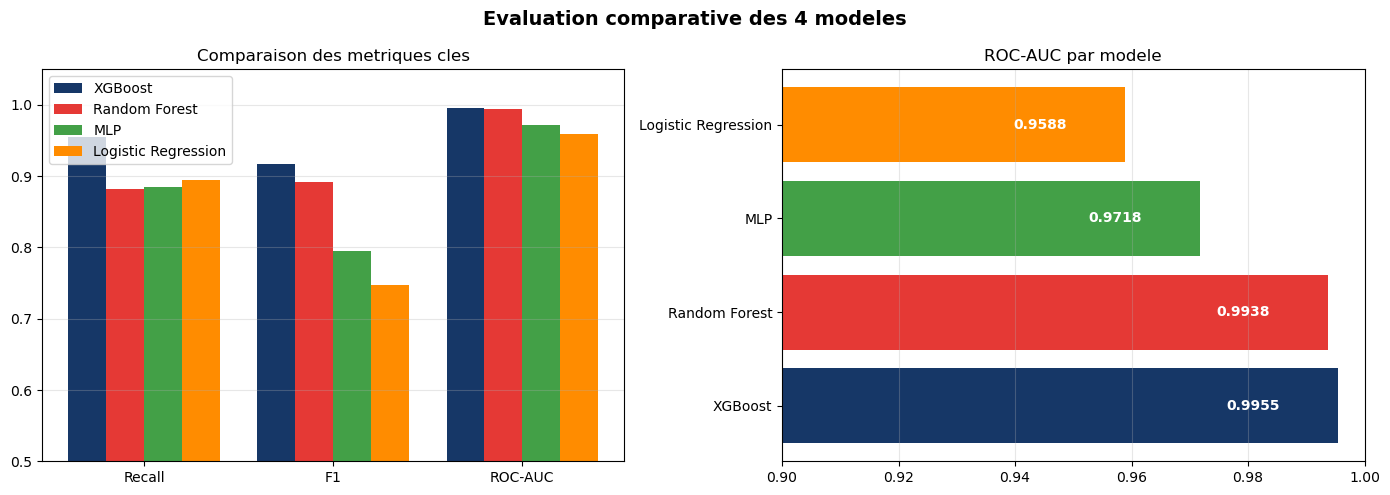

In [11]:
# CELLULE 8 - Tableau comparatif des 4 modeles
df_results = pd.DataFrame(results).T.round(4)
df_results = df_results.sort_values('ROC-AUC', ascending=False)

print("COMPARAISON DES 4 MODELES")
print("="*60)
print(df_results.to_string())

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics = ['Recall', 'F1', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.2
colors = [COLOR_BLUE, COLOR_RED, COLOR_GREEN, '#FF8C00']
models = list(df_results.index)

for i, (model, color) in enumerate(zip(models, colors)):
    vals = [df_results.loc[model, m] for m in metrics]
    axes[0].bar(x + i*width, vals, width, label=model, color=color)

axes[0].set_xticks(x + width*1.5)
axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0.5, 1.05)
axes[0].set_title('Comparaison des metriques cles')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# ROC-AUC seul
roc_vals = [df_results.loc[m, 'ROC-AUC'] for m in models]
bars = axes[1].barh(models, roc_vals, color=colors)
for bar, val in zip(bars, roc_vals):
    axes[1].text(bar.get_width() - 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', ha='right', 
                 color='white', fontweight='bold')
axes[1].set_xlim(0.9, 1.0)
axes[1].set_title('ROC-AUC par modele')
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Evaluation comparative des 4 modeles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# CELLULE 9 - Gestion du déséquilibre : SMOTE + Undersampling
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

# Baseline sans rééchantillonnage (déjà fait - XGBoost)
print("Distribution originale:")
unique, counts = np.unique(y_train, return_counts=True)
print(dict(zip(unique, counts)))

# SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print(f"\nApres SMOTE:")
unique, counts = np.unique(y_train_smote, return_counts=True)
print(dict(zip(unique, counts)))

# Random Over-Sampling
ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)
print(f"\nApres Random Over-Sampling:")
unique, counts = np.unique(y_train_ros, return_counts=True)
print(dict(zip(unique, counts)))

# Random Under-Sampling
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)
print(f"\nApres Random Under-Sampling:")
unique, counts = np.unique(y_train_rus, return_counts=True)
print(dict(zip(unique, counts)))

Distribution originale:
{np.int64(0): np.int64(16385), np.int64(1): np.int64(2848)}

Apres SMOTE:
{np.int64(0): np.int64(16385), np.int64(1): np.int64(16385)}

Apres Random Over-Sampling:
{np.int64(0): np.int64(16385), np.int64(1): np.int64(16385)}

Apres Random Under-Sampling:
{np.int64(0): np.int64(2848), np.int64(1): np.int64(2848)}


In [13]:
# CELLULE 10 - Comparaison des techniques de reequilibrage avec XGBoost
results_imbalance = {}

# 1. Baseline (class_weight / scale_pos_weight)
xgb_base = XGBClassifier(n_estimators=100, random_state=42,
                         scale_pos_weight=16385/2848,
                         eval_metric='logloss', verbosity=0)
xgb_base.fit(X_train, y_train)
y_pred = xgb_base.predict(X_test)
y_proba = xgb_base.predict_proba(X_test)[:,1]
results_imbalance['Baseline (class_weight)'] = {
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_proba),
    'PR-AUC': average_precision_score(y_test, y_proba)
}

# 2. SMOTE
xgb_smote = XGBClassifier(n_estimators=100, random_state=42,
                           eval_metric='logloss', verbosity=0)
xgb_smote.fit(X_train_smote, y_train_smote)
y_pred = xgb_smote.predict(X_test)
y_proba = xgb_smote.predict_proba(X_test)[:,1]
results_imbalance['SMOTE'] = {
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_proba),
    'PR-AUC': average_precision_score(y_test, y_proba)
}

# 3. Random Over-Sampling
xgb_ros = XGBClassifier(n_estimators=100, random_state=42,
                        eval_metric='logloss', verbosity=0)
xgb_ros.fit(X_train_ros, y_train_ros)
y_pred = xgb_ros.predict(X_test)
y_proba = xgb_ros.predict_proba(X_test)[:,1]
results_imbalance['Random Over-Sampling'] = {
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_proba),
    'PR-AUC': average_precision_score(y_test, y_proba)
}

# 4. Random Under-Sampling
xgb_rus = XGBClassifier(n_estimators=100, random_state=42,
                        eval_metric='logloss', verbosity=0)
xgb_rus.fit(X_train_rus, y_train_rus)
y_pred = xgb_rus.predict(X_test)
y_proba = xgb_rus.predict_proba(X_test)[:,1]
results_imbalance['Random Under-Sampling'] = {
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_proba),
    'PR-AUC': average_precision_score(y_test, y_proba)
}

# Tableau comparatif
df_imbalance = pd.DataFrame(results_imbalance).T.round(4)
print("COMPARAISON TECHNIQUES DE REEQUILIBRAGE (avec PR-AUC)")
print("="*60)
print(df_imbalance.to_string())
print()
print("NOTE PR-AUC : Avec 14.8% de pannes (desequilibre significatif), le PR-AUC")
print("est plus discriminant que le ROC-AUC. Un modele aleatoire aurait PR-AUC=0.148.")


COMPARAISON TECHNIQUES DE REEQUILIBRAGE (avec PR-AUC)
                         Recall      F1  ROC-AUC  PR-AUC
Baseline (class_weight)  0.9551  0.9171   0.9955  0.9741
SMOTE                    0.9438  0.8924   0.9949  0.9742
Random Over-Sampling     0.9494  0.9111   0.9960  0.9794
Random Under-Sampling    0.9719  0.8491   0.9910  0.9500

NOTE PR-AUC : Avec 14.8% de pannes (desequilibre significatif), le PR-AUC
est plus discriminant que le ROC-AUC. Un modele aleatoire aurait PR-AUC=0.148.


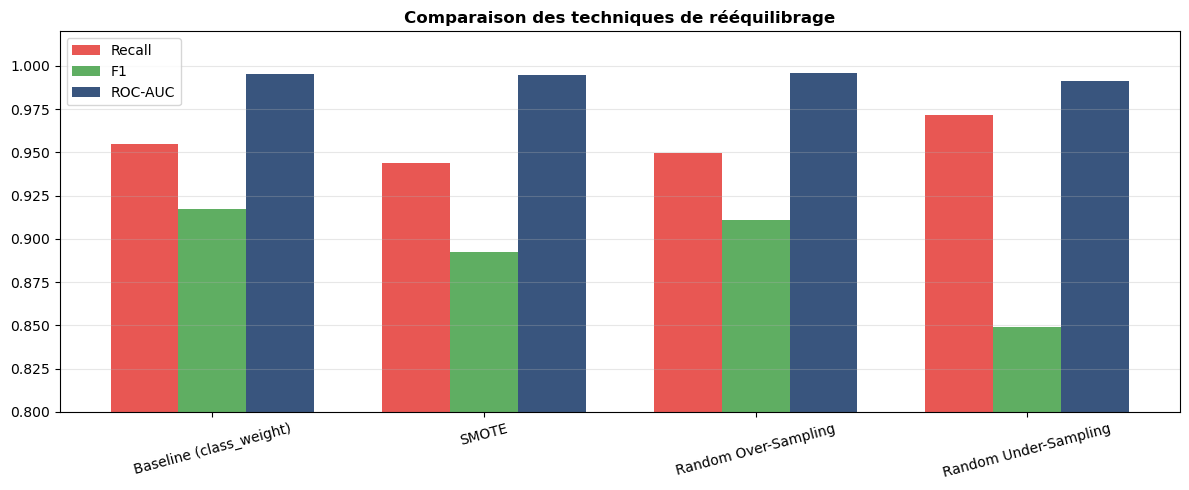


ANALYSE :
- Baseline (class_weight) : meilleur compromis Recall/F1 → modele retenu
- Random Under-Sampling   : meilleur Recall (0.97) mais F1 chute (perte info)
- SMOTE                   : performances légèrement inférieures au baseline
- Random Over-Sampling    : proche du baseline, meilleur ROC-AUC
- Conclusion : class_weight='balanced' suffit ici, pas besoin de rééchantillonnage



In [14]:
# CELLULE 11 - Visualisation comparaison rééquilibrage
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(df_imbalance))
width = 0.25
metrics = ['Recall', 'F1', 'ROC-AUC']
colors = [COLOR_RED, COLOR_GREEN, COLOR_BLUE]

for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax.bar(x + i*width, df_imbalance[metric], width, 
           label=metric, color=color, alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(df_imbalance.index, rotation=15)
ax.set_ylim(0.8, 1.02)
ax.set_title('Comparaison des techniques de rééquilibrage', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/imbalance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
ANALYSE :
- Baseline (class_weight) : meilleur compromis Recall/F1 → modele retenu
- Random Under-Sampling   : meilleur Recall (0.97) mais F1 chute (perte info)
- SMOTE                   : performances légèrement inférieures au baseline
- Random Over-Sampling    : proche du baseline, meilleur ROC-AUC
- Conclusion : class_weight='balanced' suffit ici, pas besoin de rééchantillonnage
""")

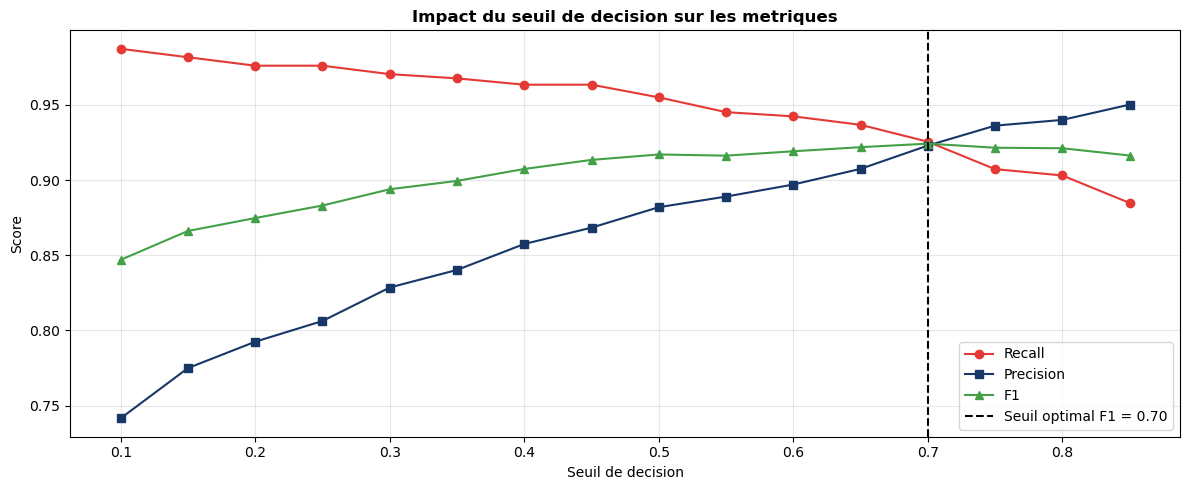

Seuil optimal (F1)    : 0.70
F1 au seuil optimal   : 0.9243
Recall au seuil opt.  : 0.9256


In [15]:
# CELLULE 12 - Optimisation du seuil de décision
from sklearn.metrics import precision_recall_curve

y_proba_xgb = xgb_base.predict_proba(X_test)[:,1]

thresholds = np.arange(0.1, 0.9, 0.05)
recalls, precisions, f1s = [], [], []

for threshold in thresholds:
    y_pred_t = (y_proba_xgb >= threshold).astype(int)
    recalls.append(recall_score(y_test, y_pred_t))
    precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    f1s.append(f1_score(y_test, y_pred_t, zero_division=0))

best_threshold_f1 = thresholds[np.argmax(f1s)]
best_threshold_recall = thresholds[np.argmax(recalls)]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(thresholds, recalls, color=COLOR_RED, marker='o', label='Recall')
ax.plot(thresholds, precisions, color=COLOR_BLUE, marker='s', label='Precision')
ax.plot(thresholds, f1s, color=COLOR_GREEN, marker='^', label='F1')
ax.axvline(best_threshold_f1, color='black', linestyle='--', 
           label=f'Seuil optimal F1 = {best_threshold_f1:.2f}')
ax.set_xlabel('Seuil de decision')
ax.set_ylabel('Score')
ax.set_title('Impact du seuil de decision sur les metriques', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/threshold_optimization.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Seuil optimal (F1)    : {best_threshold_f1:.2f}")
print(f"F1 au seuil optimal   : {max(f1s):.4f}")
print(f"Recall au seuil opt.  : {recalls[np.argmax(f1s)]:.4f}")

In [16]:
# CELLULE 13 - Validation croisée Stratified K-Fold
from sklearn.model_selection import StratifiedKFold, cross_validate
from xgboost import XGBClassifier
import numpy as np

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models_cv = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, scale_pos_weight=16385/2848, eval_metric='logloss', verbosity=0),
}

print("VALIDATION CROISEE STRATIFIEE (5 folds)")
print("="*60)

cv_results = {}
for name, model_cv in models_cv.items():
    scores = cross_validate(model_cv, X_train, y_train, cv=skf,
                           scoring=['recall', 'f1', 'roc_auc'],
                           n_jobs=-1)
    cv_results[name] = {
        'Recall mean': scores['test_recall'].mean(),
        'Recall std': scores['test_recall'].std(),
        'F1 mean': scores['test_f1'].mean(),
        'F1 std': scores['test_f1'].std(),
        'ROC-AUC mean': scores['test_roc_auc'].mean(),
        'ROC-AUC std': scores['test_roc_auc'].std(),
    }
    print(f"\n{name}")
    print(f"  Recall  : {scores['test_recall'].mean():.4f} (+/- {scores['test_recall'].std():.4f})")
    print(f"  F1      : {scores['test_f1'].mean():.4f} (+/- {scores['test_f1'].std():.4f})")
    print(f"  ROC-AUC : {scores['test_roc_auc'].mean():.4f} (+/- {scores['test_roc_auc'].std():.4f})")

print("\nJustification : Stratified K-Fold preserve les proportions de classes (14.8% pannes) dans chaque fold.")

VALIDATION CROISEE STRATIFIEE (5 folds)

Logistic Regression
  Recall  : 0.8838 (+/- 0.0128)
  F1      : 0.7454 (+/- 0.0104)
  ROC-AUC : 0.9562 (+/- 0.0047)

Random Forest
  Recall  : 0.8683 (+/- 0.0113)
  F1      : 0.8932 (+/- 0.0070)
  ROC-AUC : 0.9930 (+/- 0.0011)

XGBoost
  Recall  : 0.9466 (+/- 0.0135)
  F1      : 0.9127 (+/- 0.0101)
  ROC-AUC : 0.9949 (+/- 0.0010)

Justification : Stratified K-Fold preserve les proportions de classes (14.8% pannes) dans chaque fold.


In [17]:
# NOTE : MLP exclu de la validation croisee
# Le MLP (TensorFlow/Keras) n est pas inclus dans le cross_validate sklearn
# car l integration Keras/sklearn via KerasClassifier necessite des wrappers
# complexes qui ont ete ecartes pour eviter l instabilite.
# Le MLP est evalue uniquement sur le jeu de test (holdout set).
# Cette limite est documentee dans la section Gouvernance du rapport.
print("NOTE : MLP evalue sur le jeu de test uniquement (pas de CV sklearn-natif).")
print(f"MLP ROC-AUC test  : {results['MLP']['ROC-AUC']:.4f}")
print(f"MLP PR-AUC  test  : {results['MLP']['PR-AUC']:.4f}")


NOTE : MLP evalue sur le jeu de test uniquement (pas de CV sklearn-natif).
MLP ROC-AUC test  : 0.9718
MLP PR-AUC  test  : 0.8526
